## Assignment 2: $k$ Nearest Neighbor

### Do any four.

In [37]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor , KNeighborsClassifier
from scipy.stats import gaussian_kde
from sklearn.metrics import accuracy_score, confusion_matrix , mean_squared_error
from sklearn.preprocessing import StandardScaler , MinMaxScaler

**Q1.** Please answer the following questions.
1. What is the difference between regression and classification?
2. What is a confusion table/matrix? What does it help us understand about a model's performance? 
3. What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?
4. What does the root mean squared error quantify about a particular model?
5. What are overfitting and underfitting? 
6. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?
7. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Answers:**

1. Regression predicts a continuous numeric output by fitting a line, classification predicts a discrete output or class label.
2. A confusion table/matrix compares predicted vs actual labels, showing true/false positives and negatives. It gives a detailed breakdown of errors in the model, showing correct and incorrect preditions. 
3. Accuracy is the proportion of correct predictions over the total numbers of predictions. It may not be entirely sufficient to evaluate performance because it can not differentiate erros and looks at false positives and false negatives the same. 
4. Root mean squared error measures the average size of prediction errors in a regression model, in the same units as the dependent variable. It is highly sensitive to outliers due to the fact that it squares errors before averaging them.
5. Overfitting is when a model is too complex and learns too much from the training data, performing poorly on new data. Underfitting is when a model is too simple to capture the underlying pattern, performing poorly everywhere.
6. Splitting the data into training and testing sets ensures the model is evaluated on new information, so it does not memorize the training data and overfit the model. Choosing $k$ by evaluating accuracy or RMSE allows you to pick which one generalizes best based on real world scenarios. 
7. Predicting a class label is simple and clear but does not fully show uncertain information (which can be bad for the prediction). Predicting a probability distribution allows you to adjust decision thresholds and show confidence levels, but can require extra human verificaiton/interpretation after the model runs.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

In [31]:
print('2.1')
df = pd.read_csv('./data/land_mines.csv')
print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nTarget distribution:")
print(df['mine_type'].value_counts().sort_index())
print("\nDescribe:")
print(df.describe())

2.1
Shape: (338, 4)

Column names: ['voltage', 'height', 'soil', 'mine_type']

Target distribution:
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

Describe:
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000


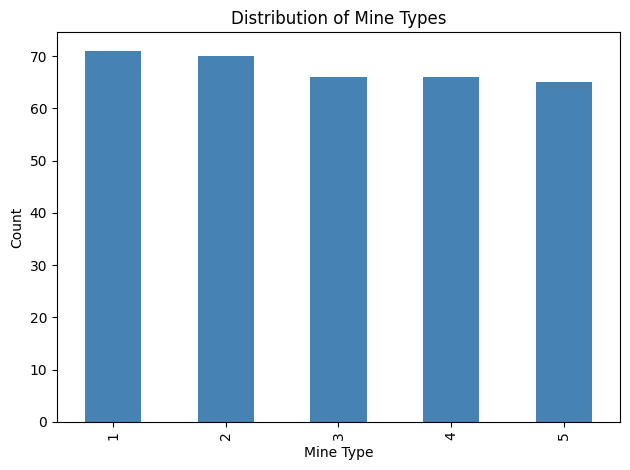

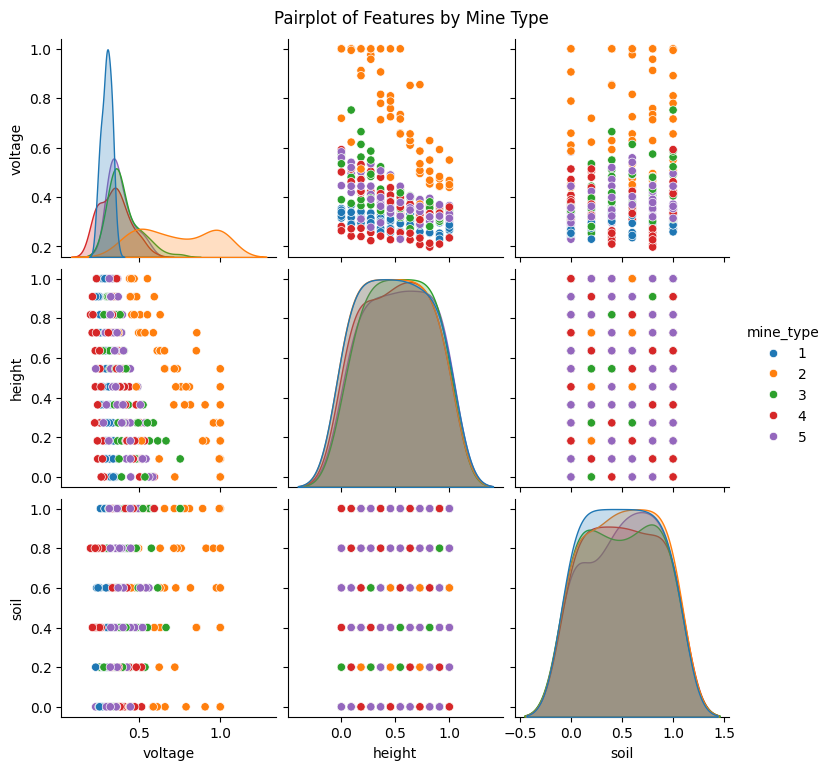

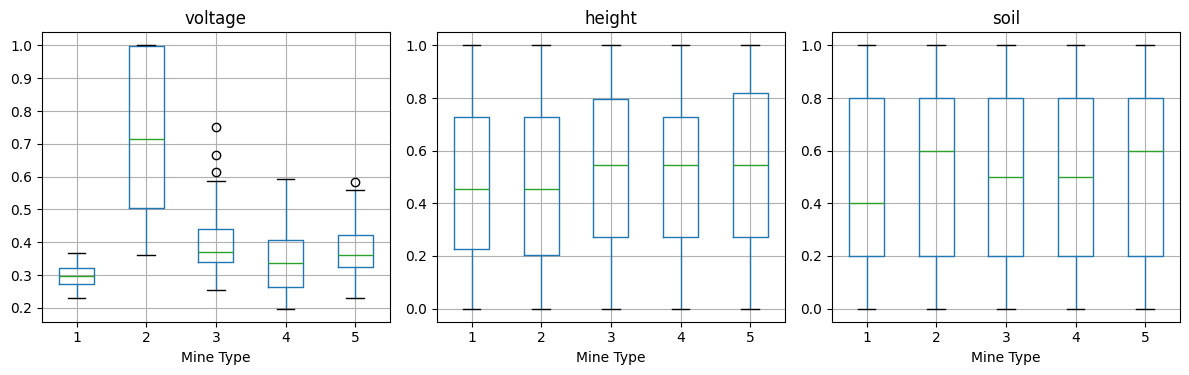

In [32]:
df['mine_type'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribution of Mine Types')
plt.xlabel('Mine Type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

sns.pairplot(df, hue='mine_type', vars=['voltage', 'height', 'soil'], palette='tab10')
plt.suptitle('Pairplot of Features by Mine Type', y=1.02)
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ['voltage', 'height', 'soil']):
    df.boxplot(column=col, by='mine_type', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Mine Type')
plt.suptitle('')
plt.tight_layout()
plt.show()

In [33]:
print('2.2')
X = df[['voltage', 'height', 'soil']].values
y = df['mine_type'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42, stratify=y
)
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

2.2

Train size: 169, Test size: 169


2.3

Best k: 1 with test accuracy: 0.5089


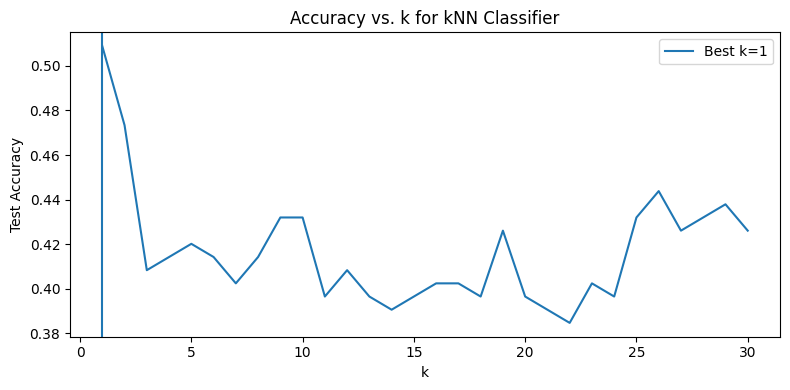

In [34]:
print('2.3')
accuracies = {}
for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    acc = accuracy_score(y_test, knn.predict(X_test))
    accuracies[k] = acc

best_k = max(accuracies, key=accuracies.get)
print(f"\nBest k: {best_k} with test accuracy: {accuracies[best_k]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(accuracies.keys()), list(accuracies.values()))
plt.axvline(x=best_k, label=f'Best k={best_k}')
plt.xlabel('k')
plt.ylabel('Test Accuracy')
plt.title('Accuracy vs. k for kNN Classifier')
plt.legend()
plt.tight_layout()
plt.show()

To select k, I tried every value from 1 to 30 and measured accuracy on the test set for each one. I chose the k that gave the highest accuracy because the test set is data the model has never seen, so accuracy on it is a fair measure of how well the model actually generalizes rather than just memorizing the training data.

2.4

Overall Accuracy: 0.5089

Confusion Matrix (rows=actual, cols=predicted):
          Pred 1  Pred 2  Pred 3  Pred 4  Pred 5
Actual 1      22       0       3       3       8
Actual 2       0      32       0       3       0
Actual 3       7       0      10       9       7
Actual 4       6       5       4      13       5
Actual 5       6       0      10       7       9

Per-class accuracy:
  Mine type 1: 61.11%
  Mine type 2: 91.43%
  Mine type 3: 30.30%
  Mine type 4: 39.39%
  Mine type 5: 28.12%


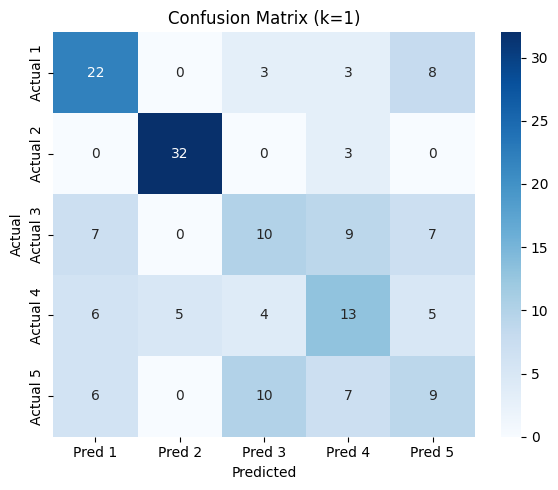

In [35]:
print('2.4')
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train, y_train)
y_pred = knn_best.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
overall_acc = accuracy_score(y_test, y_pred)

print(f"\nOverall Accuracy: {overall_acc:.4f}")
print("\nConfusion Matrix (rows=actual, cols=predicted):")
cm_df = pd.DataFrame(cm,
                     index=[f'Actual {i}' for i in sorted(np.unique(y))],
                     columns=[f'Pred {i}' for i in sorted(np.unique(y))])
print(cm_df)

print("\nPer-class accuracy:")
for i, mine in enumerate(sorted(np.unique(y))):
    class_acc = cm[i, i] / cm[i, :].sum()
    print(f"  Mine type {mine}: {class_acc:.2%}")

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (k={best_k})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Looking at the confusion matrix, the model tends to perform best on mine types where the values don't overlap much with other types (such as mine 1 and 2). Performance is weaker on types that share similar feature values with another type, since the model gets confused between them.

2.5 

The way I'd advise someone to use the model would be as a starting point and not allow it to be a final decision about their predictions. You should not always assume the model is right because it can make mistakes, so it is good to always manually verify the model after running it. 

**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?
5. Determine the optimal $k$ for these data.
6. Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)

In [52]:
print('3.1')
df = pd.read_csv('./data/USA_cars_datasets.csv')
df = df[['price', 'year', 'mileage']]
print("Shape:", df.shape)
print("\nNAs:\n", df.isnull().sum())
print("\nHead:\n", df.head())

3.1
Shape: (2499, 3)

NAs:
 price      0
year       0
mileage    0
dtype: int64

Head:
    price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654


In [53]:
print('3.2')
for col in ['year', 'mileage']:
    df[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

3.2


In [54]:
print('3.3')
X = df[['year', 'mileage']].values
y = df['price'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

3.3


3.4


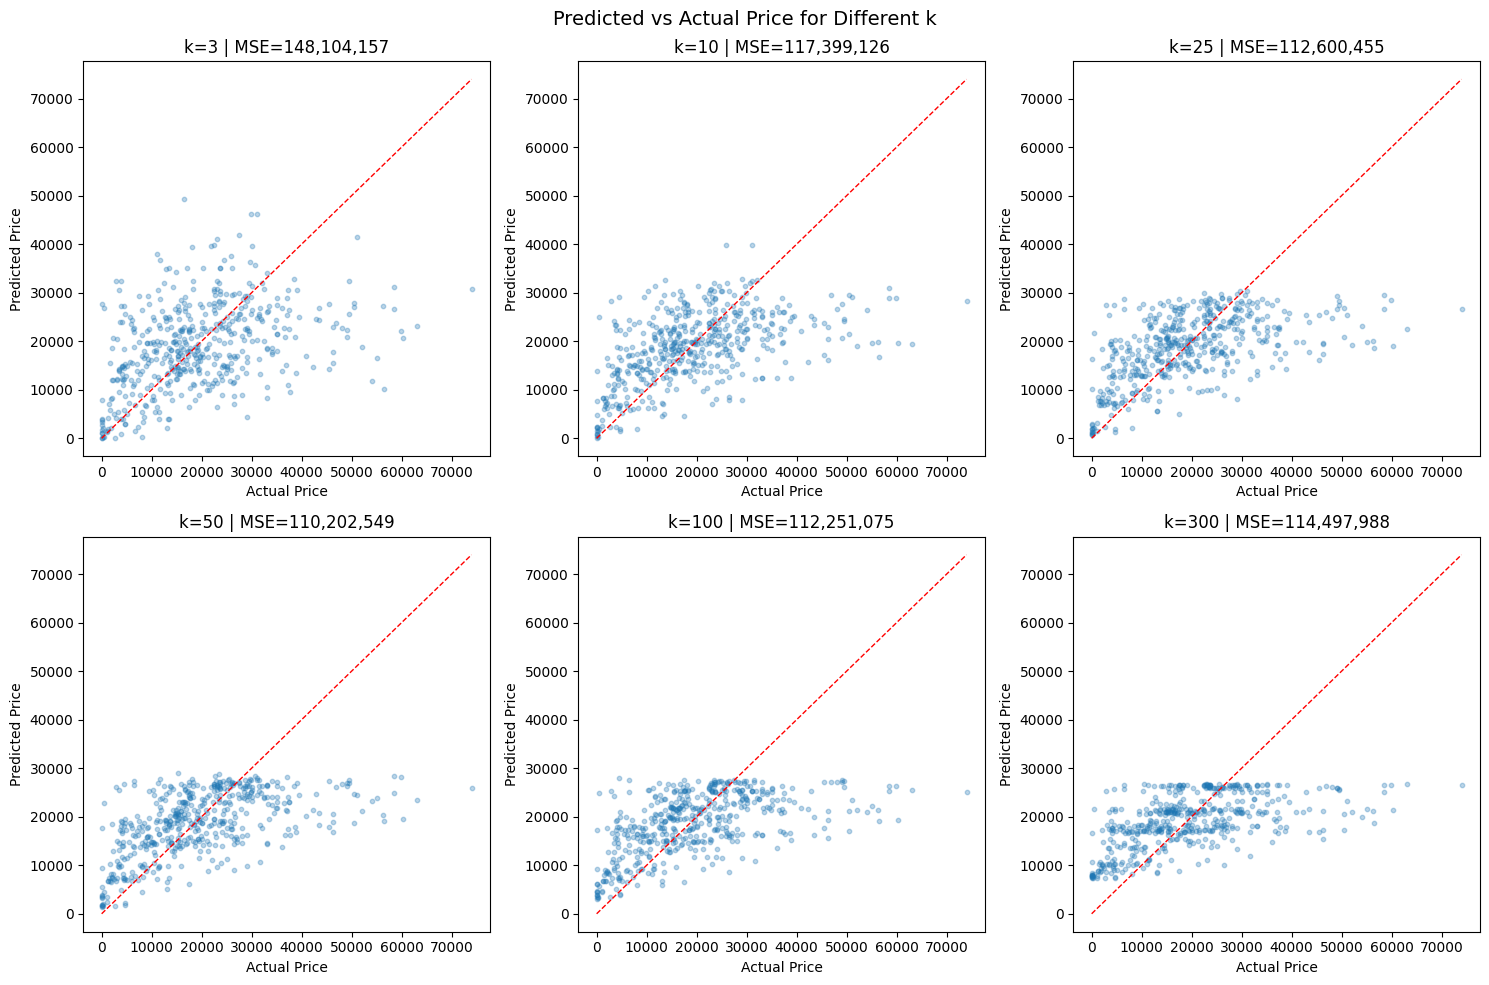


MSE by k:
  k=3: 148,104,157.19
  k=10: 117,399,126.11
  k=25: 112,600,455.16
  k=50: 110,202,549.30
  k=100: 112,251,075.34
  k=300: 114,497,987.76


In [56]:
print('3.4')
k_values = [3, 10, 25, 50, 100, 300]
mse_results = {}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, k in enumerate(k_values):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mse_results[k] = mse

    axes[i].scatter(y_test, y_pred, alpha=0.3, s=10)
    axes[i].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                 'r--', linewidth=1)
    axes[i].set_title(f'k={k} | MSE={mse:,.0f}')
    axes[i].set_xlabel('Actual Price')
    axes[i].set_ylabel('Predicted Price')

plt.suptitle('Predicted vs Actual Price for Different k', fontsize=14)
plt.tight_layout()
plt.show()

print("\nMSE by k:")
for k, mse in mse_results.items():
    print(f"  k={k}: {mse:,.2f}")


As k increases, the predictions become smoother and more condensed.

3.5

Optimal k: 50 with MSE: 110,202,549.30


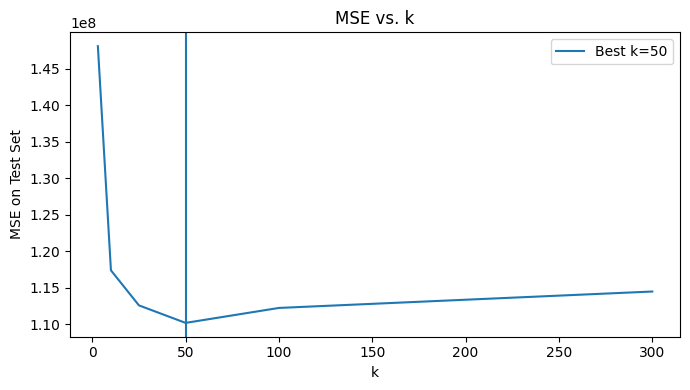

In [48]:
print('3.5')
best_k = min(mse_results, key=mse_results.get)
print(f"\nOptimal k: {best_k} with MSE: {mse_results[best_k]:,.2f}")

plt.figure(figsize=(7, 4))
plt.plot(list(mse_results.keys()), list(mse_results.values()))
plt.axvline(x=best_k, label=f'Best k={best_k}')
plt.xlabel('k')
plt.ylabel('MSE on Test Set')
plt.title('MSE vs. k')
plt.legend()
plt.tight_layout()
plt.show()

3.6 

At small k (like k=3), the model is overfitting bc predictions are scattered since the model is sensitive to individual training points. As k increases, the predictions become smoother and more compressed toward the mean, because it is averaging over more neighbors. At very large k (like k=300), the model is underfitting bc it predicts nearly the same value for everything, so the scatter plot looks more flat than diagonal. The optimal k is in the middle, where the predicted vs actual plot clusters most tightly around the red diagonal line.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings. 
6. Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.

In [39]:
print('6.1')
df = pd.read_csv('airbnb_hw.csv')
df = df.loc[:, ['Review Scores Rating', 'Price', 'Beds']]
df.head()

6.1


,Review Scores Rating,Price,Beds
0,NaN,145,1.0
1,NaN,37,1.0
2,NaN,28,1.0
3,NaN,199,3.0
4,96.0,549,3.0


In [40]:
print('6.2')
df['Price'] = df['Price'].replace('[\$,]', '', regex=True).astype(float)

missing_df = df.loc[df['Review Scores Rating'].isnull()]
missing_df.head()

6.2


,Review Scores Rating,Price,Beds
0,NaN,145.0,1.0
1,NaN,37.0,1.0
2,NaN,28.0,1.0
3,NaN,199.0,3.0
13,NaN,68.0,1.0


In [41]:
print('6.3')
df = df.dropna(axis=0, how='any')
df.head()

6.3


,Review Scores Rating,Price,Beds
4,96.0,549.0,3.0
5,100.0,149.0,1.0
6,100.0,250.0,1.0
7,94.0,90.0,1.0
8,90.0,270.0,2.0


6.4

Best k: 46 with SSE: 321221.90


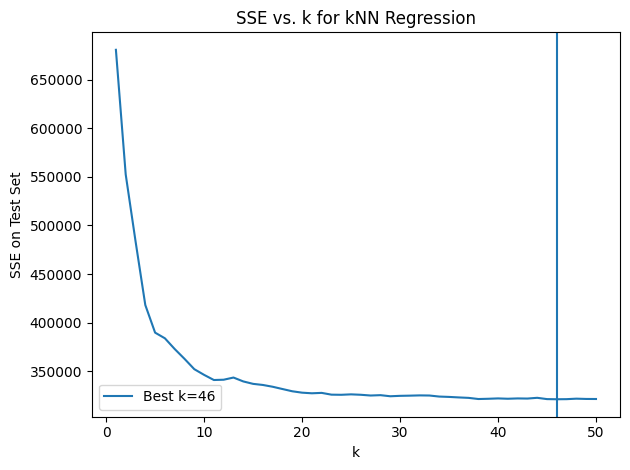

In [46]:
print('6.4')

X = df[['Price', 'Beds']].values
y = df['Review Scores Rating'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

sse_results = {}
k_values = range(1, 51)

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    sse = np.sum((y_test - y_pred) ** 2)
    sse_results[k] = sse

best_k = min(sse_results, key=sse_results.get)
print(f"\nBest k: {best_k} with SSE: {sse_results[best_k]:.2f}")

plt.plot(list(sse_results.keys()), list(sse_results.values()))
plt.axvline(x=best_k, label=f'Best k={best_k}')
plt.xlabel('k')
plt.ylabel('SSE on Test Set')
plt.title('SSE vs. k for kNN Regression')
plt.legend()
plt.tight_layout()
plt.show()

I chose k by trying a range of values of k and computing the SSE on the test set for each one. The k with the lowest SSE on the test set is the one I used because the test set gives an honest measure of how well each k generalizes to new data rather than just fitting the training observations.

In [47]:
print('6.5') 
knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X, y)

X_missing = missing_df[['Price', 'Beds']].dropna().values
X_missing_scaled = scaler.transform(X_missing) # Use the scaler from 6.4
predicted_ratings = knn_final.predict(X_missing_scaled)

print(f"\nPredicted ratings summary:")
print(f"  Mean: {predicted_ratings.mean():.2f}")
print(f"  Std:  {predicted_ratings.std():.2f}")
print(f"  Min:  {predicted_ratings.min():.2f}")
print(f"  Max:  {predicted_ratings.max():.2f}")

6.5

Predicted ratings summary:
  Mean: 86.65
  Std:  0.00
  Min:  86.65
  Max:  86.65


6.6


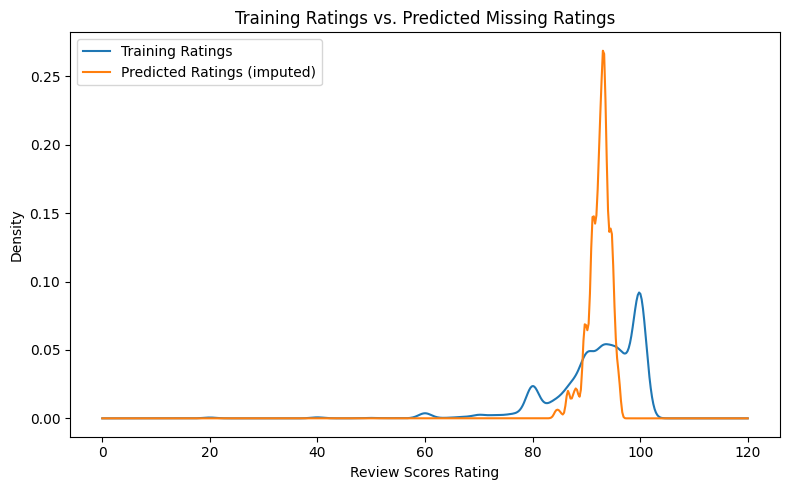

In [31]:
print('6.6')
fig, ax = plt.subplots(figsize=(8, 5))

kde_train = gaussian_kde(y)
x_range = np.linspace(0, 120, 500)
ax.plot(x_range, kde_train(x_range), label='Training Ratings')

kde_pred = gaussian_kde(predicted_ratings)
ax.plot(x_range, kde_pred(x_range), label='Predicted Ratings (imputed)')

ax.set_xlabel('Review Scores Rating')
ax.set_ylabel('Density')
ax.set_title('Training Ratings vs. Predicted Missing Ratings')
ax.legend()
plt.tight_layout()
plt.show()

The imputed ratings see a much more skinny and tall distribution while peaking around 90, while the training ratings are more spread out and short while peaking around 100.